In [1]:
# !pip install --no-cache-dir --no-deps --force-reinstall --upgrade "git+https://github.com/Sea-Meets-the-Stars/llc4320-native-grid-preprocessing.git" # for llc data

In [2]:
print("test")

test


In [3]:
from tqdm import tqdm
from torchinfo import summary
import matplotlib.pyplot as plt
import data_proc.data_preproc as data_preproc
import dino.dino_features as features
import cutouts.cutouts as cutouts
import numpy as np

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import umap.umap_ as umap

/home/jovyan/conda_envs/torch_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import torch
from sklearn.neighbors import KNeighborsClassifier

In [5]:
print(torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("torch cuda version:", torch.version.cuda)
print("compiled with cuda:", torch.backends.cuda.is_built())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

2.10.0+cu130
cuda available: True
torch cuda version: 13.0
compiled with cuda: True
device: cuda


# Data

In [6]:
img_net_loader, img_net_loader_val = data_preproc.get_dataloaders(data = "tiny_imagenet", size=64)

cuda


In [11]:
eruo_sat_loader, eruo_sat_loader_val = data_preproc.get_dataloaders(data = "eurosat_rgb", size=64)

In [12]:
uc_merced_loader, uc_merced_loader_val = data_preproc.get_dataloaders(data = "uc_merced", size=64)

In [54]:
eddy_loader, eddy_loader_val = data_preproc.get_dataloaders(data = "eddy", size=64)

In [7]:
llc_loader, llc_loader_val = cutouts.get_cutout_loaders()

/home/jovyan/conda_envs/torch_env/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46171 instead
  warnings.warn(


url : https://jupyterhub-west.nrp-nautilus.io/hub/user-redirect/proxy/46171/status
Any NaN: True
Any +inf: False
Any -inf: False
Total NaNs: 95
Total infs: 0
Number of patches containing NaN: 7
First 10 bad patch indices: [5877 7509 7979 8549 8825 8964 8967]
Old shape: (9000, 8, 64, 64)
New shape: (8993, 8, 64, 64)
Any NaN: True
Any +inf: False
Any -inf: False
Total NaNs: 3
Total infs: 0
Number of patches containing NaN: 1
First 10 bad patch indices: [7277]


In [ ]:
# from tqdm import tqdm
# import torch
# print()
# def std_mean(loader):
#     sum_c = np.zeros(3)
#     sum_sq_c = np.zeros(3)
#     n_pixels = 0

#     for batch in tqdm(loader, total=len(loader)):
#         x = batch["image"].cpu()
#         finite = torch.isfinite(x)
#         arr_clean = torch.where(finite, x, torch.zeros_like(x))

#         arr = np.array(arr_clean.numpy())
#         arr = np.transpose(arr, (0, 2, 3, 1))
#         pixels = arr.reshape(-1, 3)



#         sum_c += np.nansum(pixels, axis=0) #.sum(axis=0)
#         sum_sq_c += (pixels ** 2).sum(axis=0)
#         n_pixels += pixels.shape[0]



#     mean = sum_c / n_pixels
#     var = sum_sq_c / n_pixels - mean ** 2
#     var = np.clip(var, a_min=0, a_max=None)
#     std = np.sqrt(var)
#     #
#     # std = np.sqrt(sum_sq_c / n_pixels - mean ** 2)


#     print("mean:", mean)
#     print("std:", std)

# std_mean(llc_loader)

torch.Size([64, 3, 64, 64])
shape: torch.Size([64, 3, 64, 64])
dtype: torch.float32
device: cpu
min: -3.2724571228027344
max: 3.0525808334350586
nan count: 0
inf count: 0


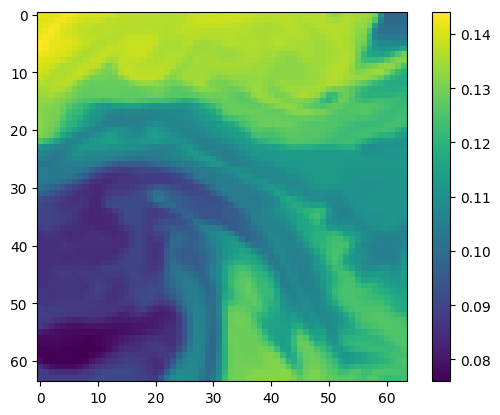

In [8]:
for batch in llc_loader_val:

    images = batch["image"]
    labels = batch["label"]
    print(images.shape)

    img = images[0][1]

    plt.imshow(img)
    plt.colorbar()

    images = batch["image"]
    print("shape:", images.shape)
    print("dtype:", images.dtype)
    print("device:", images.device)
    print("min:", images.min().item())
    print("max:", images.max().item())
    print("nan count:", torch.isnan(images).sum().item())
    print("inf count:", torch.isinf(images).sum().item())
    break

In [55]:
def plot_eddy_samples(X, labels, n_samples=5):
    idx = [1,2,3,5]

    fig, axes = plt.subplots(n_samples, 4, figsize=(12, 3*n_samples))

    for r, i in enumerate(idx):
        eta = X[i, 0]
        theta  = X[i, 1]
        salt = X[i,2]

        def norm(x):
            return x #(x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x) + 1e-8)

        im0 = axes[r,0].imshow(norm(eta), cmap="viridis", origin="lower")
        axes[r,0].set_title("SST")
        fig.colorbar(im0, ax=axes[r,0])

        im1 = axes[r,1].imshow(norm(theta), cmap="viridis", origin="lower")
        axes[r,1].set_title("CHLA")
        fig.colorbar(im1, ax=axes[r,1])

        im2 = axes[r,2].imshow(norm(salt), cmap="viridis", origin="lower")
        axes[r,2].set_title("sea level")
        fig.colorbar(im1, ax=axes[r,2])

        axes[r,3].text(
            0.5, 0.5, f"class {labels[i]}",
            ha="center", va="center", fontsize=14
        )
        axes[r,3].set_title("label")
        axes[r,3].set_xticks([])
        axes[r,3].set_yticks([])

        for c in range(3):
            axes[r,c].set_xticks([])
            axes[r,c].set_yticks([])

    plt.tight_layout()
    plt.show()

[tensor(0), tensor(1), tensor(0), tensor(1), tensor(0), tensor(2), tensor(0), tensor(1), tensor(2), tensor(1), tensor(2), tensor(0), tensor(2), tensor(0), tensor(1)]


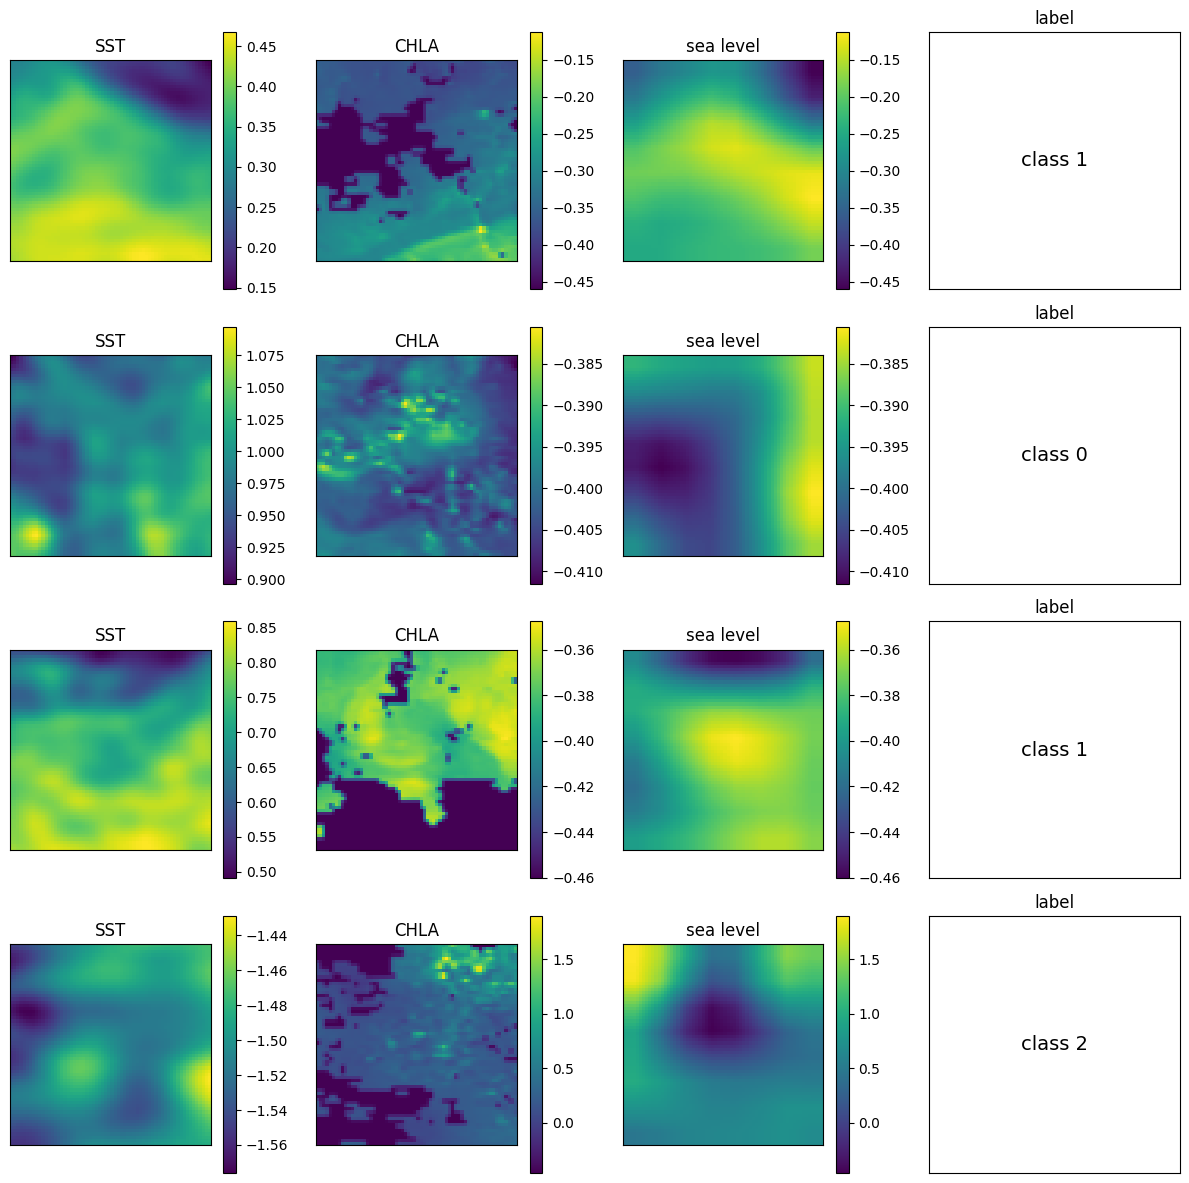

In [56]:
X = []
y = []
for batch in eddy_loader_val:

    X.append(batch["image"][0])
    y.append(batch["label"][0])

    if len(X) > 50:
        break

print (y)
plot_eddy_samples(np.array(X), np.array(y), n_samples=4)

torch.Size([64, 3, 64, 64])
shape: torch.Size([64, 3, 64, 64])
dtype: torch.float32
device: cpu
min: -4.239274024963379
max: 59.63933563232422
nan count: 0
inf count: 0


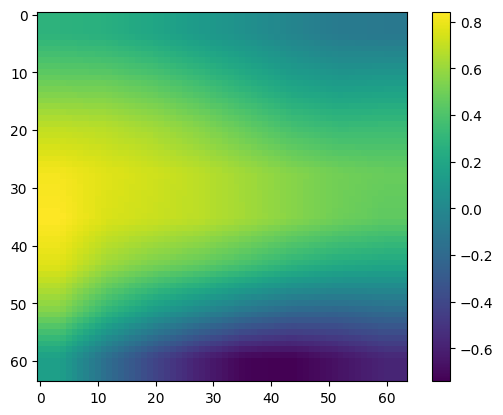

In [16]:
for batch in eddy_loader_val:

    images = batch["image"]
    labels = batch["label"]
    print(images.shape)

    img = images[0][2]

    plt.imshow(img)
    plt.colorbar()

    images = batch["image"]
    print("shape:", images.shape)
    print("dtype:", images.dtype)
    print("device:", images.device)
    print("min:", images.min().item())
    print("max:", images.max().item())
    print("nan count:", torch.isnan(images).sum().item())
    print("inf count:", torch.isinf(images).sum().item())
    break

torch.Size([64, 3, 64, 64])


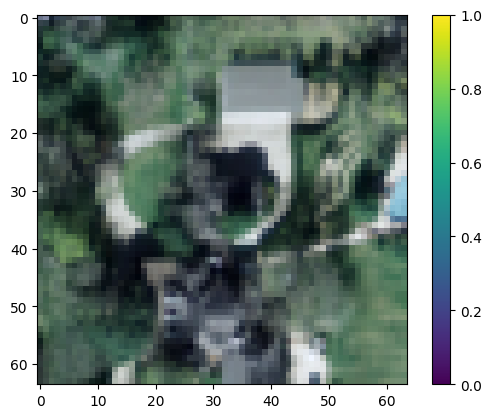

In [17]:
for batch in uc_merced_loader_val:

    images = batch["image"]
    labels = batch["label"]
    print(images.shape)

    img = images[1].permute(1, 2, 0)#.cpu()

    img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img)
    plt.colorbar()
    break

torch.Size([64, 3, 64, 64])


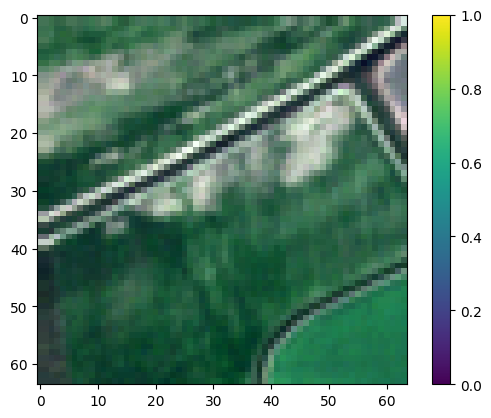

In [18]:
for batch in eruo_sat_loader_val:

    images = batch["image"]
    labels = batch["label"]
    print(images.shape)

    img = images[1].permute(1, 2, 0)#.cpu()

    img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img)
    plt.colorbar()
    break


In [28]:
len(eruo_sat_loader)

254

torch.Size([64, 3, 64, 64])


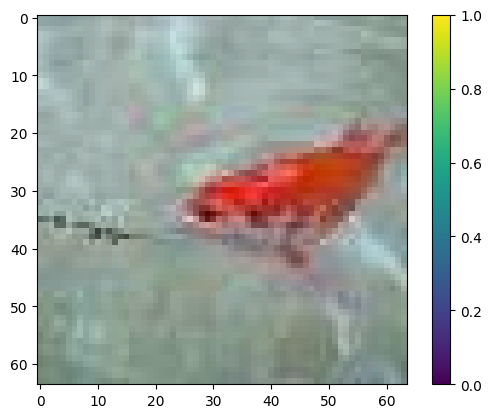

In [19]:
for batch in img_net_loader_val:

    images = batch["image"]
    labels = batch["label"]
    print(images.shape)

    img = images[1].permute(1, 2, 0)#.cpu()

    img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img)
    plt.colorbar()
    break

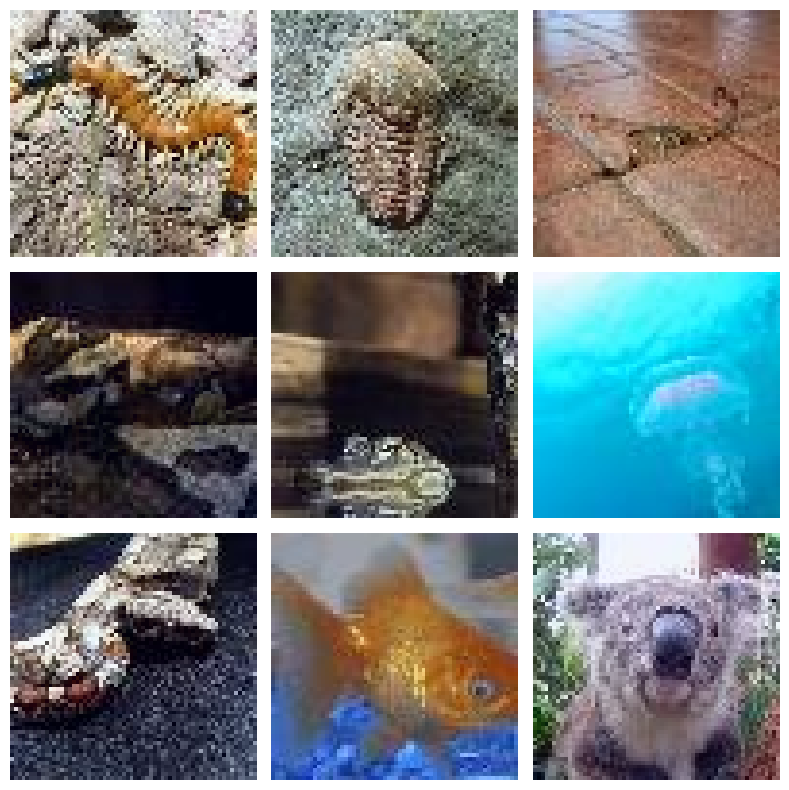

In [22]:
# collect a few batches so we can sample randomly
all_images = []
all_labels = []
for batch in img_net_loader_val:
    all_images.append(batch["image"])
    all_labels.append(batch["label"])
    if len(all_images) > 10:   # enough pool for randomness
        break

images = torch.cat(all_images, dim=0)

# pick 9 random indices
idxs = torch.randperm(images.shape[0])[:9]

fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for ax, idx in zip(axes.flatten(), idxs):
    img = images[idx].permute(1, 2, 0)

    # normalize per image for display
    img = (img - img.min()) / (img.max() - img.min())

    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Features

In [19]:
model = torch.hub.load('facebookresearch/dino:main', 'dino_vits8')
model.eval()
model.to("cuda")

Using cache found in /home/jovyan/.cache/torch/hub/facebookresearch_dino_main


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(8, 8), stride=(8, 8))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
  (head): Identity()
)

In [41]:
subsample_percent = 10
model.eval().to(device)

X_tiny_image_net, y_tiny_image_net = features.frozen_features(model, img_net_loader, device, subsample_percent=None, data_type="tiny_image_net")
X_val_tiny_image_net, y_val_tiny_image_net = features.frozen_features(model, img_net_loader_val, device, subsample_percent=None, data_type="tiny_image_net")

100%|██████████| 1563/1563 [01:03<00:00, 24.56it/s]


torch.Size([100000, 384]) torch.Size([100000])



100%|██████████| 157/157 [00:06<00:00, 24.28it/s]

torch.Size([10000, 384]) torch.Size([10000])


In [40]:
subsample_percent = 10
model.eval().to(device)

X_eruosat_rgb, y_eruosat_rgb = features.frozen_features(model, eruo_sat_loader, device, subsample_percent=None, data_type="tiny_image_net")
X_val_eruosat_rgb, y_val_eruosat_rgb = features.frozen_features(model, eruo_sat_loader_val, device, subsample_percent=None, data_type="tiny_image_net")

100%|██████████| 254/254 [00:11<00:00, 21.54it/s]


torch.Size([16200, 384]) torch.Size([16200])



100%|██████████| 85/85 [00:03<00:00, 21.81it/s]

torch.Size([5400, 384]) torch.Size([5400])


In [39]:
subsample_percent = 10
model.eval().to(device)

X_uc_merced, y_uc_merced = features.frozen_features(model, uc_merced_loader, device, subsample_percent=None, data_type="tiny_image_net")
X_val_uc_merced, y_val_uc_merced = features.frozen_features(model, uc_merced_loader_val, device, subsample_percent=None, data_type="tiny_image_net")

100%|██████████| 27/27 [06:04<00:00, 13.49s/it]


torch.Size([1680, 384]) torch.Size([1680])



100%|██████████| 7/7 [00:27<00:00,  3.95s/it]

torch.Size([420, 384]) torch.Size([420])


In [38]:
subsample_percent = 10
model.eval().to(device)

X_eddy, y_eddy = features.frozen_features(model, eddy_loader, device, subsample_percent=None, data_type="tiny_image_net")
X_val_eddy, y_val_eddy = features.frozen_features(model, eddy_loader_val, device, subsample_percent=None, data_type="tiny_image_net")

100%|██████████| 61/61 [01:26<00:00,  1.42s/it]


torch.Size([3892, 384]) torch.Size([3892])



100%|██████████| 15/15 [00:20<00:00,  1.38s/it]

torch.Size([950, 384]) torch.Size([950])


In [37]:
model.eval().to(device)

X_llc, y_llc = features.frozen_features(model, llc_loader, device, subsample_percent=None, data_type="tiny_image_net")
X_val_llc, y_val_llc = features.frozen_features(model, llc_loader_val, device, subsample_percent=None, data_type="tiny_image_net")

100%|██████████| 113/113 [00:04<00:00, 22.79it/s]


torch.Size([7186, 384]) torch.Size([7186])



100%|██████████| 29/29 [00:00<00:00, 29.18it/s]

torch.Size([1797, 384]) torch.Size([1797])


In [45]:
def knn_score(X, y, X_val, y_val, k=5):
    neigh = KNeighborsClassifier(n_neighbors=k)
    neigh.fit(X, y)

    print(neigh.score(X_val, y_val))

# Zero Shot

In [47]:
from sklearn.linear_model import LogisticRegression

def linear_probe_score(X, y, X_val, y_val, max_iter=2000, C=1.0):
    """
    Linear probe using multinomial logistic regression.

    X, X_val: [N, D] feature arrays
    y, y_val: [N] labels
    """
    
    mu = X.mean(axis=0)
    sigma = X.std(axis=0) + 1e-6

    Xn = (X - mu) / sigma
    Xvn = (X_val - mu) / sigma

    clf = LogisticRegression(
        max_iter=max_iter,
        C=C,
        solver="lbfgs",
        verbose=2
    )
    clf.fit(Xn, y)

    acc = clf.score(Xvn, y_val)
    print("linear probe accuracy:", acc)
    return acc, clf

In [22]:
def X_y_from_loader(train_loader, val_loader):

    X, y = [], []
    X_val, y_val = [], []

    for batch in tqdm(train_loader, total=len(train_loader)):
        images = batch["image"]           # [B, C, H, W]
        labels = batch["label"]

        images = images.view(images.size(0), -1)  # flatten
        X.append(images.cpu())
        y.append(labels.cpu())

    for batch in tqdm(val_loader, total=len(val_loader)):
        images = batch["image"]
        labels = batch["label"]

        images = images.view(images.size(0), -1)
        X_val.append(images.cpu())
        y_val.append(labels.cpu())

    X = torch.cat(X).numpy()
    y = torch.cat(y).numpy()

    X_val = torch.cat(X_val).numpy()
    y_val = torch.cat(y_val).numpy()

    return X, y, X_val, y_val

In [32]:
raw_img_net_X, raw_img_net_y, raw_img_net_X_val, raw_img_net_y_val = X_y_from_loader(img_net_loader, img_net_loader_val)
knn_score(raw_img_net_X, raw_img_net_y, raw_img_net_X_val, raw_img_net_y_val, k=5)

0.0291


In [43]:
knn_score(X_tiny_image_net, y_tiny_image_net, X_val_tiny_image_net, y_val_tiny_image_net, k=5)

0.6731


KeyboardInterrupt: 

In [45]:
linear_probe_score(X_tiny_image_net, y_tiny_image_net, X_val_tiny_image_net, y_val_tiny_image_net, max_iter=100, C=1.0)

linear probe accuracy: 0.6826


/home/jovyan/conda_envs/torch_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


(0.6826, LogisticRegression(verbose=2))

In [47]:
#EUROSAT 

raw_eurosat_X, raw_eurosat_y, raw_eurosat_X_val, raw_eurosat_y_val = X_y_from_loader(eruo_sat_loader, eruo_sat_loader_val)
knn_score(raw_eurosat_X, raw_eurosat_y, raw_eurosat_X_val, raw_eurosat_y_val, k=5)

knn_score(X_eruosat_rgb, y_eruosat_rgb, X_val_eruosat_rgb, y_val_eruosat_rgb, k=5)
linear_probe_score(X_eruosat_rgb, y_eruosat_rgb, X_val_eruosat_rgb, y_val_eruosat_rgb, max_iter=2000, C=1.0)

100%|██████████| 85/85 [00:01<00:00, 42.59it/s]


0.3403703703703704
0.9461111111111111
linear probe accuracy: 0.9611111111111111


(0.9611111111111111, LogisticRegression(max_iter=2000, verbose=2))

In [48]:
# UC MERCED

raw_merced_X, raw_merced_y, raw_merced_X_val, raw_merced_y_val = X_y_from_loader(uc_merced_loader, uc_merced_loader_val)
knn_score(raw_merced_X, raw_merced_y, raw_merced_X_val, raw_merced_y_val, k=5)

knn_score(X_uc_merced, y_uc_merced, X_val_uc_merced, y_val_uc_merced, k=5)
linear_probe_score(X_uc_merced, y_uc_merced, X_val_uc_merced, y_val_uc_merced, max_iter=2000, C=1.0)

100%|██████████| 7/7 [00:00<00:00, 16.63it/s]


0.16904761904761906
0.9119047619047619
linear probe accuracy: 0.9642857142857143


(0.9642857142857143, LogisticRegression(max_iter=2000, verbose=2))

In [ ]:
#EDDY 
knn_score(X_eddy, y_eddy, X_val_eddy, y_val_eddy, k=5)
linear_probe_score(X_eddy, y_eddy, X_val_eddy, y_val_eddy, max_iter=2000, C=1.0)

In [52]:
raw_eddy_X, raw_eddy_y, raw_eddy_X_val, raw_eddy_y_val = X_y_from_loader(eddy_loader, eddy_loader_val)
knn_score(raw_eddy_X, raw_eddy_y, raw_eddy_X_val, raw_eddy_y_val, k=5)

100%|██████████| 15/15 [00:06<00:00,  2.28it/s]


0.8231578947368421


In [29]:
raw_llc_X, raw_llc_y, raw_llc_X_val, raw_llc_val = X_y_from_loader(llc_loader, llc_loader_val)

100%|██████████| 29/29 [00:00<00:00, 150.15it/s]


In [30]:
len(raw_llc_X)

7186

In [47]:
knn_score(X_llc, y_llc, X_val_llc, y_val_llc, k=5)

knn_score_from_loader(llc_loader, llc_loader_val, k=5)

linear_probe_score(X_llc, y_llc, X_val_llc, y_val_llc, max_iter=2000, C=1.0)

0.6805787423483584
raw data: 0.5420144685587089
linear probe accuracy: 0.781858653311074


(0.781858653311074, LogisticRegression(max_iter=2000, verbose=True))

# Clustering

In [53]:
from sklearn.cluster import KMeans

def run_kmeans_and_count(X, y, seed=42):
    n_classes = len(np.unique(y))
    kmeans = KMeans(n_clusters=n_classes, random_state=seed, n_init=10)
    clusters = kmeans.fit_predict(X)

    counts = np.zeros((n_classes, n_classes), dtype=int)
    for c, label in zip(clusters, y):
        counts[c, label] += 1

    return clusters, counts, kmeans

In [54]:
from sklearn.cluster import AgglomerativeClustering

def run_agglomerative_and_count(X, y):
    n_classes = len(np.unique(y))

    model = AgglomerativeClustering(n_clusters=n_classes)
    clusters = model.fit_predict(X)

    counts = np.zeros((n_classes, n_classes), dtype=int)
    for c, label in zip(clusters, y):
        counts[c, label] += 1

    return clusters, counts, model

In [55]:
X_val_tiny_image_net_norm = X_val_tiny_image_net / np.linalg.norm(X_val_tiny_image_net, axis=1, keepdims=True)

clusters, counts, kmeans = run_kmeans_and_count(X_val_tiny_image_net_norm, y_val_tiny_image_net)

print("cluster assignments shape:", clusters.shape)
print("counts:")
print(counts)

/tmp/ipykernel_965/3063479091.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  X_val_tiny_image_net_norm = X_val_tiny_image_net / np.linalg.norm(X_val_tiny_image_net, axis=1, keepdims=True)


cluster assignments shape: (10000,)
counts:
[[1 1 0 ... 0 1 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 1 1 ... 1 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [49]:
def umap_proj(X, dims=2):
    reducer = umap.UMAP(n_components=dims)
    X_d = reducer.fit_transform(X)
    return X_d

In [50]:


def vis_dim_redux(X_d, labels, class_subset=None, label_title="class", dims=2):

    # if class_subset is not None:
    #     rng = np.random.default_rng(42)
        
    #     classes = np.unique(labels)
    #     chosen = rng.choice(classes, size=class_subset, replace=False)
    
    #     idxs = []
    #     for c in chosen:
    #         c_idx = np.where(labels == c)[0]
    #         take = len(c_idx)
    #         idxs.extend(rng.choice(c_idx, size=take, replace=False))
    
    #     idxs = np.array(idxs)
    #     X = X[idxs]
    #     labels = labels[idxs]
        
    # if redux == "pca":
    #     pca = PCA(n_components=dims)
    #     X_d = pca.fit_transform(X) 
    
    # elif redux == "umap":
    #     reducer = umap.UMAP(n_components=dims, random_state=42)
    #     X_d = reducer.fit_transform(X)
        

    labels = labels

    if dims ==2:
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_subplot(111)
    
        scatter = ax.scatter(
            X_d[:,0],
            X_d[:,1],
            c=labels,
            cmap="tab10",
            s=10
        )
    
        ax.set_xlabel("C1")
        ax.set_ylabel("C2")
    
        legend = ax.legend(*scatter.legend_elements(), title=label_title)
        ax.add_artist(legend)

    if dims == 3:
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_subplot(111, projection='3d')
    
        scatter = ax.scatter(
            X_d[:,0],
            X_d[:,1],
            X_d[:,2],
            c=labels,
            cmap="tab10",
            s=10
        )
    
        ax.set_xlabel("C1")
        ax.set_ylabel("C2")
        ax.set_zlabel("C3")
    
        legend = ax.legend(*scatter.legend_elements(), title=label_title)
        ax.add_artist(legend)

plt.show()

# Imagenet

In [89]:
X_val_tiny_image_net_norm = X_val_tiny_image_net / np.linalg.norm(X_val_tiny_image_net, axis=1, keepdims=True)
img_clusters, img_counts, img_kmeans = run_kmeans_and_count(X_val_tiny_image_net_norm, y_val_tiny_image_net)

/tmp/ipykernel_965/664894505.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  X_val_tiny_image_net_norm = X_val_tiny_image_net / np.linalg.norm(X_val_tiny_image_net, axis=1, keepdims=True)


In [115]:
class_subset = 20
labels = y_val_tiny_image_net
X = X_val_tiny_image_net_norm


rng = np.random.default_rng(42)
classes = np.unique(labels)
chosen = rng.choice(classes, size=class_subset, replace=False)

idxs = []
for c in chosen:
            c_idx = np.where(labels == c)[0]
            take = len(c_idx)
            idxs.extend(rng.choice(c_idx, size=take, replace=False))
    
idxs = np.array(idxs)
X = X[idxs]
labels = labels[idxs]

img_net_X_d = umap_proj(X, 2)

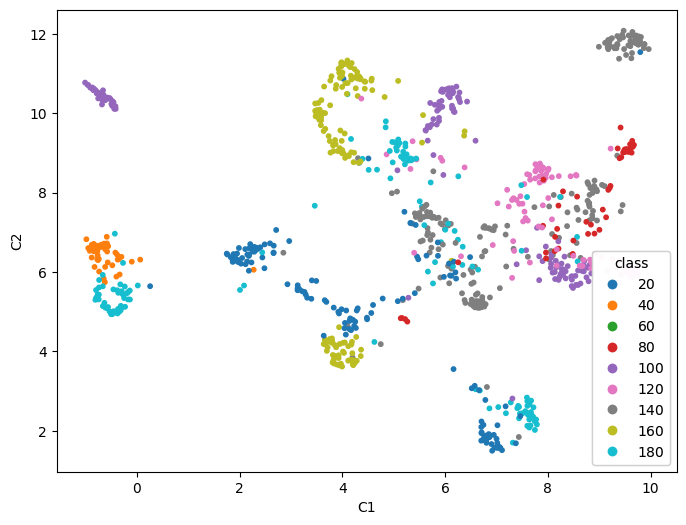

In [117]:
vis_dim_redux(img_net_X_d, labels, dims=2)

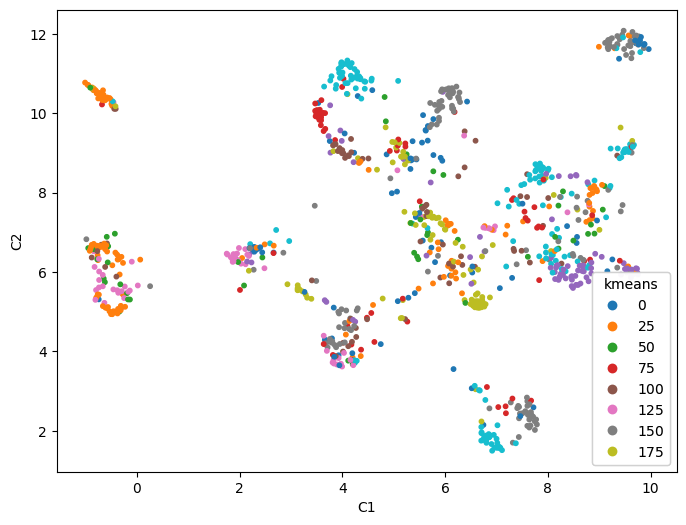

In [119]:
vis_dim_redux(img_net_X_d, img_kmeans.labels_[idxs], dims=2, label_title="kmeans")

In [120]:
_, _, img_agglom = run_agglomerative_and_count(X_val_tiny_image_net_norm, y_val_tiny_image_net)

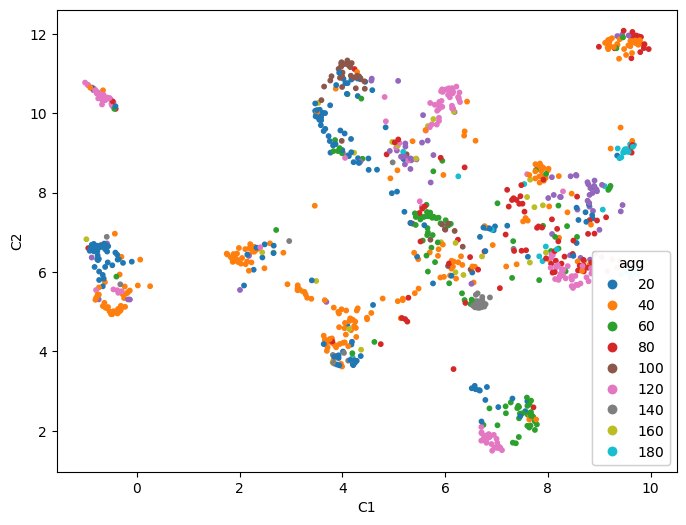

In [122]:
vis_dim_redux(img_net_X_d, img_agglom.labels_[idxs], dims=2, label_title="agg")

# Eurosat

In [82]:
X_val_eruosat_rgb_norm = X_val_eruosat_rgb / np.linalg.norm(X_val_eruosat_rgb, axis=1, keepdims=True)
eruosat_clusters, eurosat_counts, eurosat_kmeans = run_kmeans_and_count(X_val_eruosat_rgb_norm, y_val_eruosat_rgb)

print("cluster assignments shape:", clusters.shape)
print("counts:")
print(counts)



/tmp/ipykernel_965/2848573864.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  X_val_eruosat_rgb_norm = X_val_eruosat_rgb / np.linalg.norm(X_val_eruosat_rgb, axis=1, keepdims=True)


cluster assignments shape: (10000,)
counts:
[[1 1 0 ... 0 1 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 1 1 ... 1 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


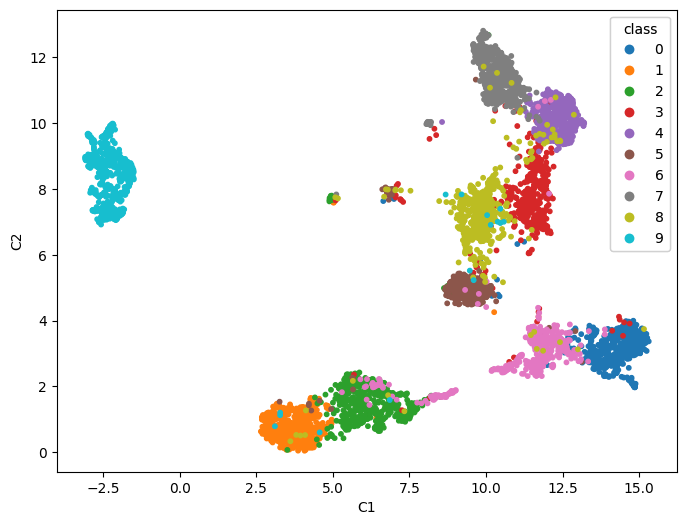

In [105]:
eurosat_X_d = umap_proj(X_val_eruosat_rgb_norm, 2)

vis_dim_redux(eurosat_X_d, y_val_eruosat_rgb)

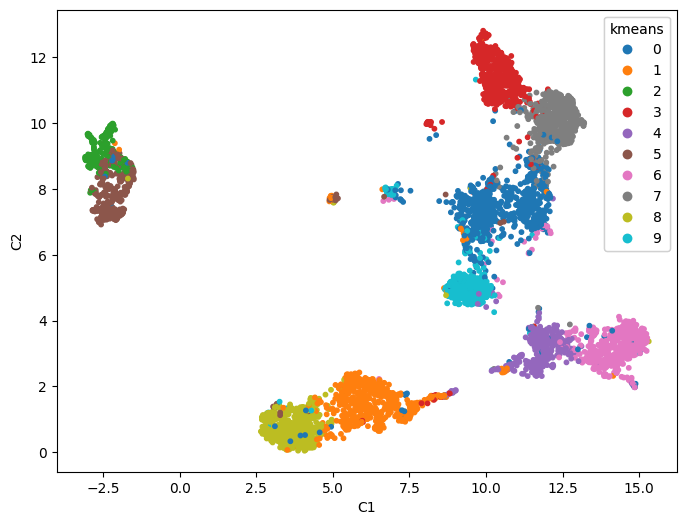

In [106]:
vis_dim_redux(eurosat_X_d, eurosat_kmeans.labels_, dims=2, label_title="kmeans")

# UCMERCED

In [123]:
X_val_ucmerced_norm = X_val_uc_merced / np.linalg.norm(X_val_uc_merced, axis=1, keepdims=True)
_, _, ucmerced_kmeans = run_kmeans_and_count(X_val_ucmerced_norm, y_val_uc_merced)
ucmerced_X_d = umap_proj(X_val_ucmerced_norm, 2)

/tmp/ipykernel_965/1642587512.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  X_val_ucmerced_norm = X_val_uc_merced / np.linalg.norm(X_val_uc_merced, axis=1, keepdims=True)


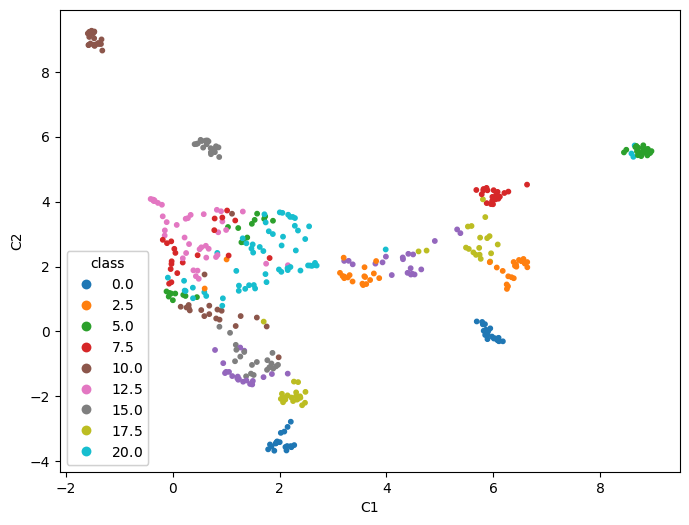

In [124]:
vis_dim_redux(ucmerced_X_d, y_val_uc_merced)

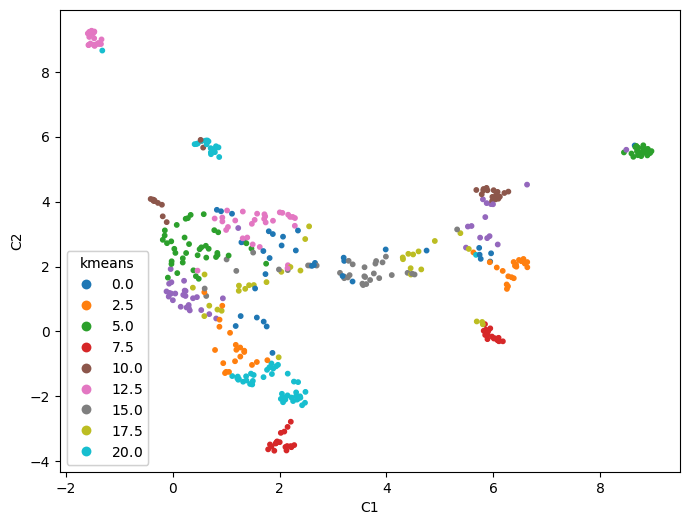

In [125]:
vis_dim_redux(ucmerced_X_d, ucmerced_kmeans.labels_, dims=2, label_title="kmeans")

# EDDY

In [62]:
X_eddy_norm = X_eddy / np.linalg.norm(X_eddy, axis=1, keepdims=True)

eddy_clusters, eddy_counts, eddy_kmeans = run_kmeans_and_count(X_eddy_norm, y_eddy)

print("cluster assignments shape:", clusters.shape)
print("counts:")
print(counts)

/tmp/ipykernel_965/551244219.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  X_eddy_norm = X_eddy / np.linalg.norm(X_eddy, axis=1, keepdims=True)


cluster assignments shape: (10000,)
counts:
[[1 1 0 ... 0 1 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 1 1 ... 1 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


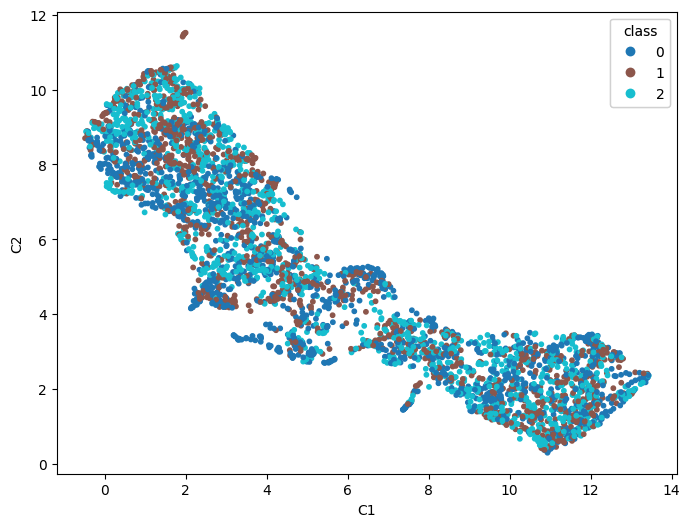

In [107]:
eddy_X_d = umap_proj(X_eddy_norm, 2)

vis_dim_redux(eddy_X_d, y_eddy, dims=2)

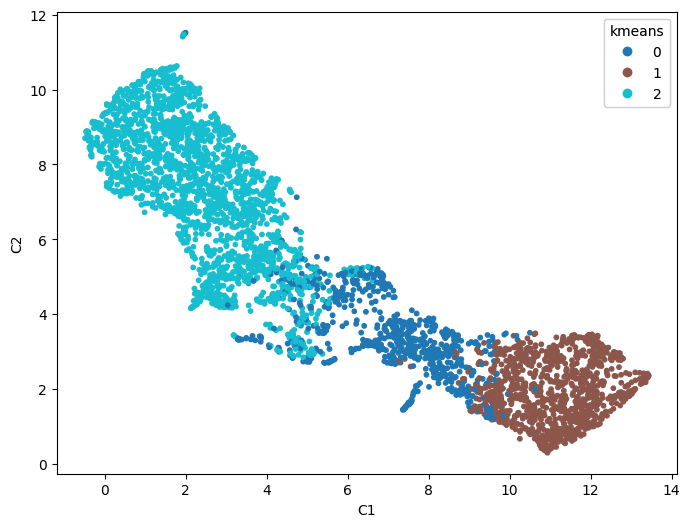

In [108]:
vis_dim_redux(eddy_X_d, eddy_kmeans.labels_, label_title="kmeans")

# LLC

In [110]:
X_llc_norm = X_llc / np.linalg.norm(X_llc, axis=1, keepdims=True)

llc_clusters, llc_counts, llc_kmeans = run_kmeans_and_count(X_llc_norm, y_llc)

print("cluster assignments shape:", llc_clusters.shape)
print("counts:")
print(llc_counts)

/tmp/ipykernel_965/2172435734.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  X_llc_norm = X_llc / np.linalg.norm(X_llc, axis=1, keepdims=True)


cluster assignments shape: (7186,)
counts:
[[1237  782  476]
 [ 119  232 1313]
 [1039 1380  608]]


In [111]:
llc_clusters, llc_counts, llc_agglom = run_agglomerative_and_count(X_llc_norm, y_llc)

print("cluster counts matrix:")
print(llc_counts)

cluster counts matrix:
[[1062 1463  737]
 [1294  819  578]
 [  39  112 1082]]


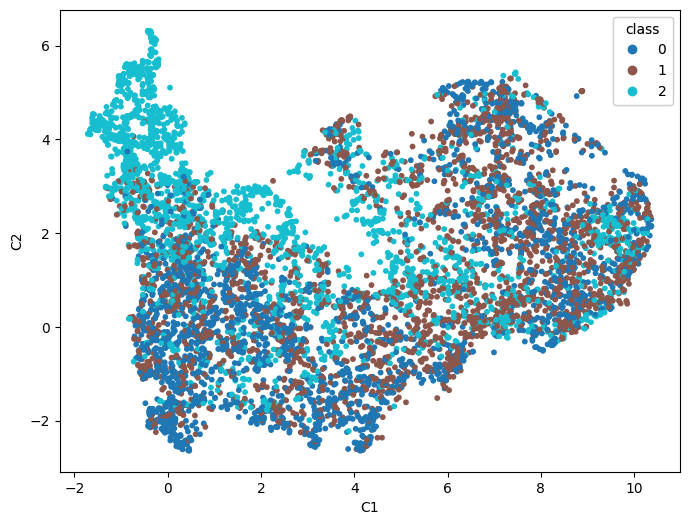

In [112]:
llc_X_d = umap_proj(X_llc_norm, 2)

vis_dim_redux(llc_X_d, y_llc, dims=2)

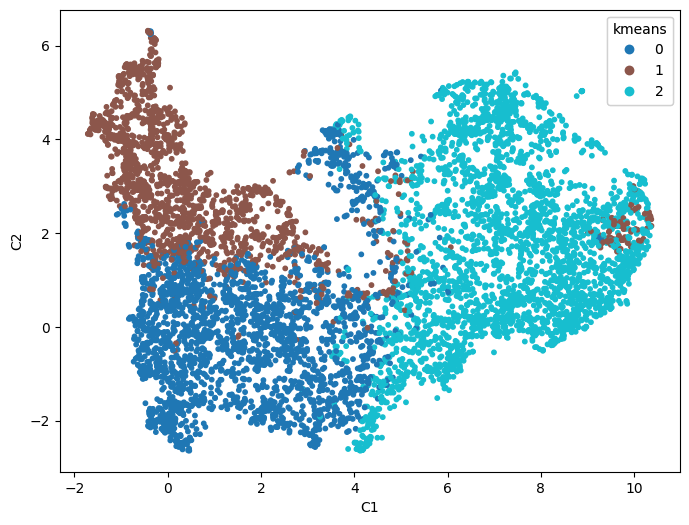

In [113]:
vis_dim_redux(llc_X_d, llc_kmeans.labels_, dims=2, label_title="kmeans")

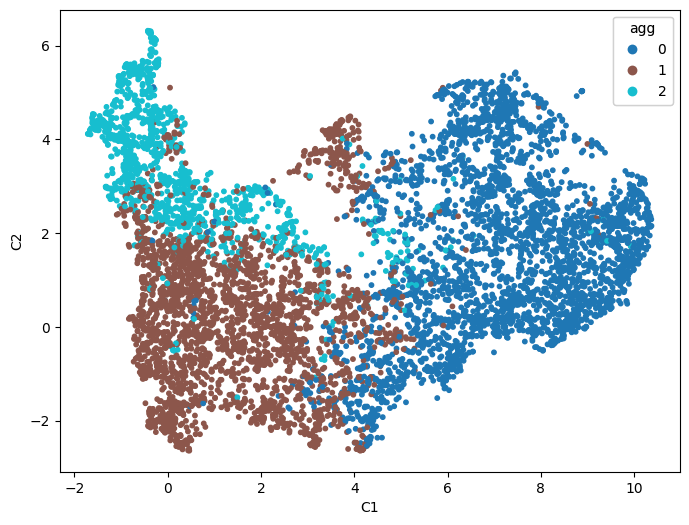

In [126]:
vis_dim_redux(llc_X_d, llc_agglom.labels_, dims=2,label_title="agg")

# CLip

In [ ]:
def extract_data_tiny_image_net(batch):
    return batch["image"], batch["label"]


def append_features(batch, device, model, all_feats, all_labels, data_type):
    if (data_type=="tiny_image_net"):
        images, labels = extract_data_tiny_image_net(batch)

    images = images.to(device, non_blocking=True).float()
    feats = model(images)  # (B, D) CLS embedding
    all_feats.append(feats.cpu())
    all_labels.append(labels.cpu())

def clip_features(model, loader, device):
    all_feats = []
    all_labels = []
    print()
    with torch.no_grad():
        for batch in tqdm(loader, total=len(loader)):
            append_features(batch, device, model, all_feats, all_labels, data_type)

    X = torch.cat(all_feats, dim=0)
    y = torch.cat(all_labels, dim=0)

    print(X.shape, y.shape)

    return X, y

In [38]:
from transformers import AutoProcessor, CLIPVisionModel

model = CLIPVisionModel.from_pretrained("openai/clip-vit-large-patch14")
# processor = AutoProcessor.from_pretrained("openai/clip-vit-large-patch14")

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 10144.08it/s]
CLIPVisionModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.embeddings.token_embedding.weight                 | UNEXPECTED |  | 
text_projection.weight                                       | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNE

In [39]:
model.eval()
model.to("cuda")

CLIPVisionModel(
  (vision_model): CLIPVisionTransformer(
    (embeddings): CLIPVisionEmbeddings(
      (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
      (position_embedding): Embedding(257, 1024)
    )
    (pre_layrnorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-23): 24 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (layer_norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=1024, out_features=4096, bias=

In [40]:
import torchvision.transforms as T

In [41]:
def clip_features(loader, model):

    transform = T.Compose([
        T.Resize(224),
        T.CenterCrop(224),
    ])
    
    all_feats = []
    all_labels = []
    
    for batch in tqdm(loader, total=len(loader)):
        pixel_values = transform(batch["image"].to("cuda"))
        with torch.no_grad():
            outputs = model(pixel_values=pixel_values)
            
            feats = outputs.pooler_output
            feats = feats / feats.norm(dim=-1, keepdim=True)

            all_feats.append(feats.cpu())
            all_labels.append(batch["label"].cpu())

    X = torch.cat(all_feats, dim=0)
    y = torch.cat(all_labels, dim=0)

    return X, y

In [42]:
clip_X_llc, llc_labels = clip_features(llc_loader, model)
clip_X_llc_val, llc_labels_val = clip_features(llc_loader_val, model)
knn_score(clip_X_llc, llc_labels, clip_X_llc_val, llc_labels_val, k=5)
linear_probe_score(clip_X_llc, llc_labels, clip_X_llc_val, llc_labels_val, max_iter=2000, C=1.0)

100%|██████████| 113/113 [01:57<00:00,  1.04s/it]


100%|██████████| 29/29 [00:28<00:00,  1.01it/s]


0.6498054474708171


linear probe accuracy: 0.7487493051695386


(0.7487493051695386, LogisticRegression(max_iter=2000, verbose=2))

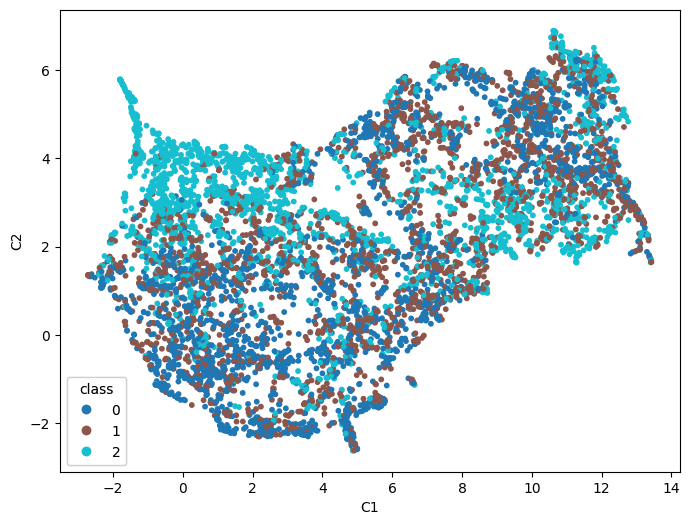

In [53]:
llc_X_d = umap_proj(clip_X_llc, 2)

vis_dim_redux(llc_X_d, llc_labels, dims=2)

100%|██████████| 15/15 [00:20<00:00,  1.40s/it]


0.66
linear probe accuracy: 0.7652631578947369


ValueError: 'c' argument has 7193 elements, which is inconsistent with 'x' and 'y' with size 3892.

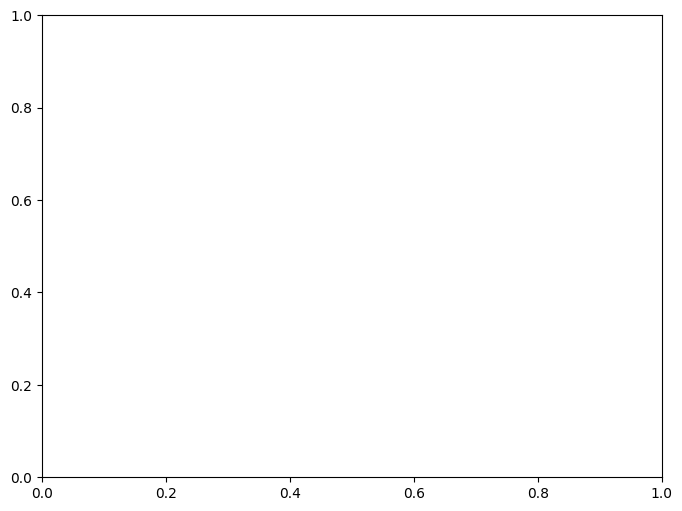

In [57]:
clip_X_eddy, eddy_labels = clip_features(eddy_loader, model)
clip_X_eddy_val, eddy_labels_val = clip_features(eddy_loader_val, model)
knn_score(clip_X_eddy, eddy_labels, clip_X_eddy_val, eddy_labels_val, k=5)
linear_probe_score(clip_X_eddy, eddy_labels, clip_X_eddy_val, eddy_labels_val, max_iter=2000, C=1.0)
eddy_X_d = umap_proj(clip_X_eddy, 2)


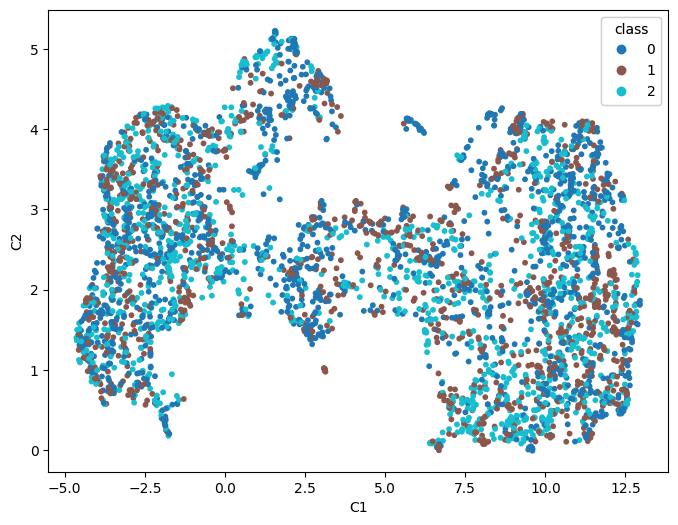

In [58]:
vis_dim_redux(eddy_X_d, eddy_labels, dims=2)

# SIMCLR